In [3]:
import numpy as np
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader,TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, accuracy_score,precision_score,recall_score,f1_score, ConfusionMatrixDisplay, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.ensemble import VotingClassifier
import matplotlib.pyplot as plt
from collections import Counter
import tiktoken
import seaborn as sns
from spacy.lang.fr.stop_words import STOP_WORDS as fr_stop
from spacy.lang.en.stop_words import STOP_WORDS as en_stop
from nltk import word_tokenize          
from nltk.stem import WordNetLemmatizer 

from gensim.models import Word2Vec

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [5]:
import torch.nn.functional as F
class RNNClassfier(nn.Module):
    def __init__(self, input_dim,hidden_dim,num_layers=1,bidrectionnal=False,dropout=0.2, num_classes=6):
        super(RNNClassfier,self).__init__()
        self.rnn = nn.RNN(input_size=input_dim,
                          hidden_size=hidden_dim,
                          num_layers= num_layers,
                          bidirectional=bidrectionnal,
                          dropout=dropout if num_layers >1 else 0)
        self.fc = nn.Linear(hidden_dim,num_classes)

    def forward(self,x):
        output,hidden = self.rnn(x)

        last_output = output[:,-1,:]
        out = self.fc(last_output)
        return out


class RNNClassifierWithAttention(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers=1, bidirectional=False, dropout=0.2, num_classes=6):
        super(RNNClassifierWithAttention, self).__init__()
        self.rnn = nn.RNN(input_size=input_dim,
                          hidden_size=hidden_dim,
                          num_layers=num_layers,
                          bidirectional=bidirectional,
                          batch_first=True,
                          dropout=dropout if num_layers > 1 else 0)
        
        self.bidirectional = bidirectional
        self.hidden_dim = hidden_dim
        real_hidden_dim = hidden_dim * 2 if bidirectional else hidden_dim

        # Attention weights layer
        self.attn = nn.Linear(real_hidden_dim, 1)

        # Classification layer
        self.fc = nn.Linear(real_hidden_dim, num_classes)

    def attention(self, rnn_outputs):
        # rnn_outputs: [batch_size, seq_len, hidden_dim]
        # Compute attention weights
        attn_scores = self.attn(rnn_outputs)  # [batch_size, seq_len, 1]
        attn_weights = F.softmax(attn_scores, dim=1)  # [batch_size, seq_len, 1]

        # Weighted sum of RNN outputs
        context = torch.sum(attn_weights * rnn_outputs, dim=1)  # [batch_size, hidden_dim]
        return context

    def forward(self, x):
        rnn_outputs, hidden = self.rnn(x)  # rnn_outputs: [batch, seq_len, hidden_dim]
        context = self.attention(rnn_outputs)  # [batch, hidden_dim]
        out = self.fc(context)
        return out

class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.001):
        """
        patience: Nombre d'époques à attendre avant d'arrêter si pas d'amélioration.
        min_delta: Amélioration minimale considérée comme significative.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0 
        else:
            self.counter += 1 
        return self.counter >= self.patience


In [6]:
def train(dataloader,model,loss_fnc,optimizer,epoch):
    model.train()
    for batch_size,(X,y) in enumerate(dataloader):
        X = X.to(device)
        y = y.to(device)
        y_pred = model(X)
        loss = loss_fnc(y_pred,y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    if epoch % 100 == 0:
        print(f"Step: {epoch} Train Loss: {loss.item():.4f}")
    return loss


def test(dataloader, model, loss_fnc, encoder):
    model.eval()
    test_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(X_batch)
            test_loss += loss_fnc(y_pred, y_batch).item()

            all_preds.append(torch.argmax(y_pred, dim=1).cpu())
            all_labels.append(y_batch.cpu())

    # Concaténer tous les batches
    y_pred = torch.cat(all_preds).numpy()
    y_true = torch.cat(all_labels).numpy()

    # Afficher le rapport
    print(f"Test Loss: {test_loss / len(dataloader):.4f}")
    print(f"Classification Report:\n", classification_report(encoder.inverse_transform(y_true), encoder.inverse_transform(y_pred)))

    # Matrice de confusion
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=encoder.classes_, yticklabels=encoder.classes_)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()


# Processing data

In [5]:
# Variable
percentage_genre_to_keep = 25
test_size = 0.05
random_state = 42

In [29]:
df = pd.read_csv("../data/MovieDataThread.csv")
index_drop = df.loc[df['imdb_id'].isnull()].index
df = df.drop(index=index_drop)
df = df.drop(columns=['imdb_id'])
df_filtered = pd.concat([df[['Script','Title']],df.filter(like='imdb_')],axis=1)
df_filtered["genre_count"] = df_filtered.filter(regex='^imdb_(?!id$)').count(axis=1)
df_filtered_one_genre = df_filtered.loc[df_filtered['genre_count'] == 1]
df_filtered_one_genre['filtered_genre'] = df_filtered_one_genre.apply(lambda row: next(iter([col for col in df_filtered_one_genre.columns if "imdb" in col and row[col] == 1.0 ]), 'unknown'), axis=1)
number_genres = len(df_filtered_one_genre['filtered_genre'].unique())
counter = Counter(df_filtered_one_genre['filtered_genre'])
sorted_list = sorted(counter.items(),reverse=True , key=lambda genre : genre[1])[: int(number_genres * (percentage_genre_to_keep / 100))]

genre_to_keep = [genre for genre,_ in sorted_list]
columns_to_keep = ['Script','filtered_genre']

df_movies = df_filtered_one_genre.loc[df_filtered_one_genre['filtered_genre'].isin(genre_to_keep)]
df_movies = df_movies[columns_to_keep].reset_index(drop=True)


C:\Users\letru\AppData\Local\Temp\ipykernel_8364\2146986483.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_one_genre['filtered_genre'] = df_filtered_one_genre.apply(lambda row: next(iter([col for col in df_filtered_one_genre.columns if "imdb" in col and row[col] == 1.0 ]), 'unknown'), axis=1)


In [30]:
df_movies.shape

(7720, 2)

# Training and test

In [7]:
X_train,X_test , y_train,y_test = train_test_split(df_movies['Script'],df_movies['filtered_genre'],test_size=test_size,random_state=random_state)

In [8]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

In [9]:
def preprocess(script):
    tokens = word_tokenize(script.lower())
    filtered = [token for token in tokens if token.isalpha() and token not in stop_words]
    return filtered

X_train__filtered_token = [preprocess(script) for script in X_train]
X_test_filtered_token = [preprocess(script) for script in X_test]

In [10]:
word2vec = Word2Vec(sentences=X_train__filtered_token, vector_size=300, window=5, min_count=2, workers=4)

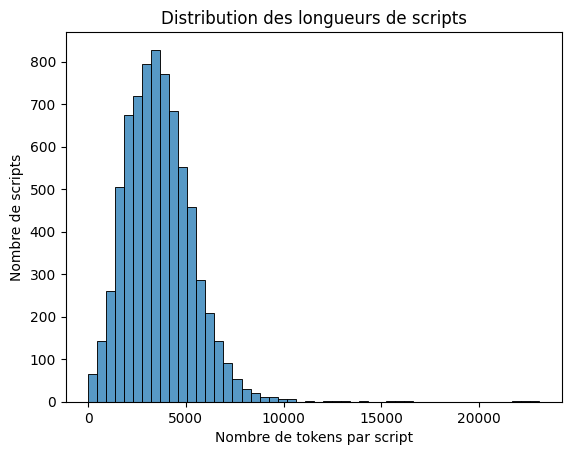

Taille max des séquences choisie : 5742


In [11]:
script_lengths = [len(tokens) for tokens in X_train__filtered_token]

sns.histplot(script_lengths, bins=50)
plt.xlabel("Nombre de tokens par script")
plt.ylabel("Nombre de scripts")
plt.title("Distribution des longueurs de scripts")
plt.show()


max_seq_len = int(np.percentile(script_lengths, 90))

print(f"Taille max des séquences choisie : {max_seq_len}")

In [12]:
from torch.utils.data import Dataset
class ScriptDatasetLazy(Dataset):
    def __init__(self, tokenized_data, labels, model, max_len=500, dim=300):
        self.data = tokenized_data
        self.labels = labels
        self.model = model
        self.max_len = max_len
        self.dim = dim

    def vectorize_and_pad(self, sentence):
        vecs = [self.model.wv[word] for word in sentence if word in self.model.wv]
        if not vecs:
            vecs = [np.zeros(self.dim)]
        vecs = vecs[:self.max_len]
        pad_len = self.max_len - len(vecs)
        if pad_len > 0:
            vecs += [np.zeros(self.dim)] * pad_len
        return np.array(vecs, dtype=np.float32)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        vec = self.vectorize_and_pad(self.data[idx])
        label = self.labels[idx]
        return torch.tensor(vec, dtype=torch.float32), torch.tensor(label, dtype=torch.long)


In [13]:
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)


y_tensor_train = torch.tensor(y_train_encoded,dtype=torch.long).view(-1)
y_tensor_test = torch.tensor(y_test_encoded,dtype=torch.long).view(-1)


train_dataset = ScriptDatasetLazy(X_train__filtered_token, y_train_encoded, word2vec, max_len=max_seq_len)
test_dataset  = ScriptDatasetLazy(X_test_filtered_token,  y_test_encoded, word2vec, max_len=max_seq_len)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

In [15]:
device = "cpu"
model = RNNClassfier(300,hidden_dim=128,num_layers=2).to(device)
early_stopping = EarlyStopping(patience=5, min_delta=0.0001)
loss_fnc = nn.CrossEntropyLoss()
optimizer_adam = torch.optim.Adam(model.parameters(),lr=0.001)
epochs = 3
for epoch in range(epochs):
    print(f"epoch: {epoch}")
    loss = train(train_loader,model,loss_fnc,optimizer_adam,epoch)
    if early_stopping(loss):
        print(f"Early stopping triggered at epoch {epoch} ")
        break


epoch: 0
Step: 0 Train Loss: 1.3524
epoch: 1
epoch: 2


Test Loss: 1.6200
Classification Report:
                   precision    recall  f1-score   support

     imdb_comedy       0.44      0.05      0.10        73
imdb_documentary       0.56      0.15      0.24        65
      imdb_drama       0.44      0.98      0.61       162
     imdb_horror       0.00      0.00      0.00        43
    imdb_romance       0.00      0.00      0.00        15
   imdb_thriller       0.00      0.00      0.00        28

        accuracy                           0.45       386
       macro avg       0.24      0.20      0.16       386
    weighted avg       0.36      0.45      0.32       386



d:\programmation\nlp\.venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\programmation\nlp\.venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\programmation\nlp\.venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


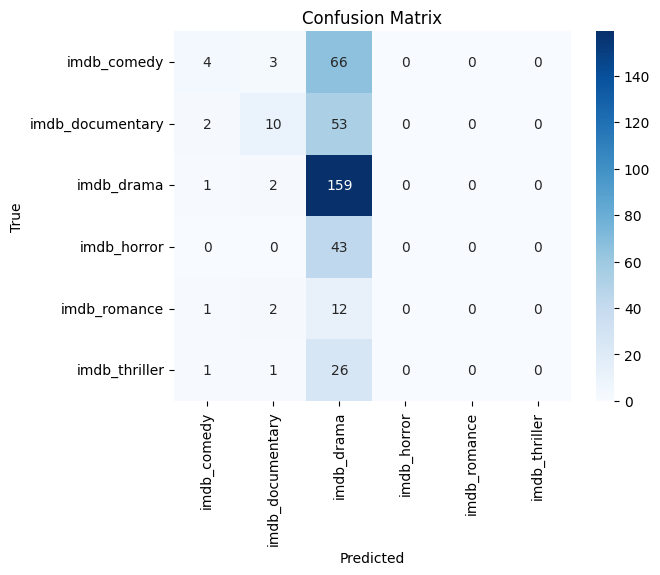

In [16]:
test(test_loader,model,loss_fnc,encoder)

# RNN with Attention


In [16]:
device = "cpu"
model = RNNClassifierWithAttention(300,hidden_dim=128,num_layers=2).to(device)
early_stopping = EarlyStopping(patience=5, min_delta=0.0001)
loss_fnc = nn.CrossEntropyLoss()
optimizer_adam = torch.optim.Adam(model.parameters(),lr=0.001)
epochs = 3
for epoch in range(epochs):
    print(f"epoch: {epoch}")
    loss = train(train_loader,model,loss_fnc,optimizer_adam,epoch)
    if early_stopping(loss):
        print(f"Early stopping triggered at epoch {epoch} ")
        break


epoch: 0
Step: 0 Train Loss: 1.1989
epoch: 1
epoch: 2


Test Loss: 0.9519
Classification Report:
                   precision    recall  f1-score   support

     imdb_comedy       0.49      0.75      0.59        73
imdb_documentary       0.83      0.89      0.86        65
      imdb_drama       0.84      0.68      0.75       162
     imdb_horror       0.56      0.81      0.66        43
    imdb_romance       0.00      0.00      0.00        15
   imdb_thriller       0.50      0.18      0.26        28

        accuracy                           0.68       386
       macro avg       0.54      0.55      0.52       386
    weighted avg       0.68      0.68      0.66       386



d:\programmation\nlp\.venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\programmation\nlp\.venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\programmation\nlp\.venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


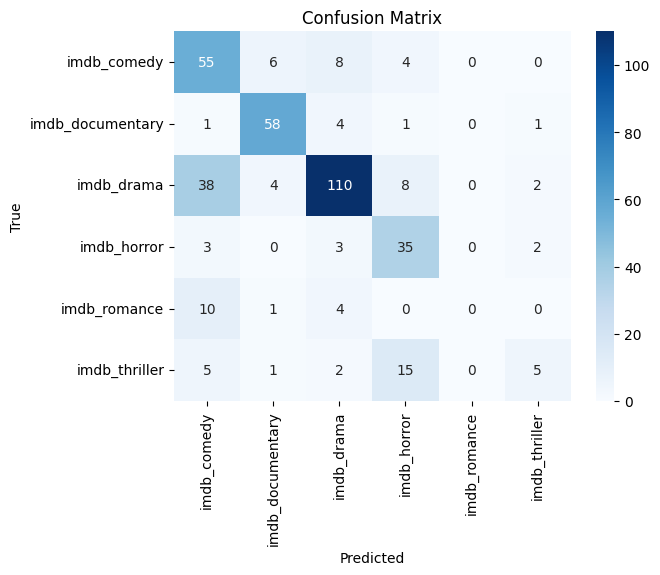

In [17]:
test(test_loader,model,loss_fnc,encoder)

# Data Augmentation

In [7]:
import pandas as pd
import random
import nltk
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /home/pierre/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/pierre/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/pierre/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/pierre/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/pierre/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [8]:
# Variable
percentage_genre_to_keep = 25
test_size = 0.05
random_state = 42

In [9]:
df = pd.read_csv("../data/MovieDataThread.csv")
index_drop = df.loc[df['imdb_id'].isnull()].index
df = df.drop(index=index_drop)
df = df.drop(columns=['imdb_id'])
df_filtered = pd.concat([df[['Script','Title']],df.filter(like='imdb_')],axis=1)
df_filtered["genre_count"] = df_filtered.filter(regex='^imdb_(?!id$)').count(axis=1)
df_filtered_one_genre = df_filtered.loc[df_filtered['genre_count'] == 1]
df_filtered_one_genre['filtered_genre'] = df_filtered_one_genre.apply(lambda row: next(iter([col for col in df_filtered_one_genre.columns if "imdb" in col and row[col] == 1.0 ]), 'unknown'), axis=1)
number_genres = len(df_filtered_one_genre['filtered_genre'].unique())
counter = Counter(df_filtered_one_genre['filtered_genre'])
sorted_list = sorted(counter.items(),reverse=True , key=lambda genre : genre[1])[: int(number_genres * (percentage_genre_to_keep / 100))]

genre_to_keep = [genre for genre,_ in sorted_list]
columns_to_keep = ['Script','filtered_genre']

df_movies = df_filtered_one_genre.loc[df_filtered_one_genre['filtered_genre'].isin(genre_to_keep)]
df_movies = df_movies[columns_to_keep].reset_index(drop=True)


/tmp/ipykernel_9360/2146986483.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_one_genre['filtered_genre'] = df_filtered_one_genre.apply(lambda row: next(iter([col for col in df_filtered_one_genre.columns if "imdb" in col and row[col] == 1.0 ]), 'unknown'), axis=1)


In [10]:
X_train,X_test , y_train,y_test = train_test_split(df_movies['Script'],df_movies['filtered_genre'],test_size=test_size,random_state=random_state)

In [11]:
len(X_train)

7334

In [12]:
# Perform augmentation
stop_words = set(stopwords.words("english"))

# Mapping NLTK POS → WordNet POS
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return None

def get_synonym(word, tag):
    wn_tag = get_wordnet_pos(tag)
    if wn_tag is None:
        return word

    synsets = wordnet.synsets(word, pos=wn_tag)
    if not synsets:
        return word

    lemmas = [lemma.name().replace("_", " ") for syn in synsets for lemma in syn.lemmas()
              if lemma.name().lower() != word.lower()]
    return random.choice(lemmas) if lemmas else word

def synonym_augment(text):
    words = word_tokenize(text)
    tagged_words = nltk.pos_tag(words)
    new_words = []

    for word, tag in tagged_words:
        if word.lower() not in stop_words and word.isalpha():
            synonym = get_synonym(word, tag)
            new_words.append(synonym)
        else:
            new_words.append(word)

    return ' '.join(new_words)

# Augment underrepresented genres
thriller_romance_indices = y_train[(y_train == 'imdb_thriller') | (y_train == 'imdb_romance')].index
thriller_romance_script = X_train.loc[thriller_romance_indices].apply(synonym_augment)

X_train = pd.concat([X_train, thriller_romance_script], ignore_index=True)
y_train = pd.concat([y_train, y_train.loc[thriller_romance_indices]], ignore_index=True)


In [13]:
len(X_train)

8196

In [14]:
def preprocess(script):
    tokens = word_tokenize(script.lower())
    filtered = [token for token in tokens if token.isalpha() and token not in stop_words]
    return filtered

X_train__filtered_token = [preprocess(script) for script in X_train]
X_test_filtered_token = [preprocess(script) for script in X_test]

In [15]:
word2vec = Word2Vec(sentences=X_train__filtered_token, vector_size=300, window=5, min_count=2, workers=4)

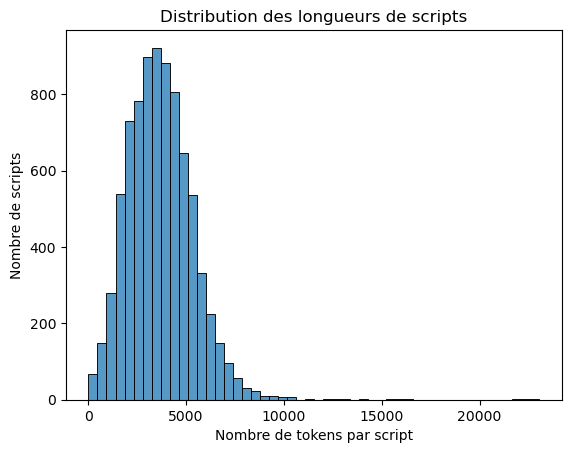

Taille max des séquences choisie : 5695


In [18]:
script_lengths = [len(tokens) for tokens in X_train__filtered_token]

sns.histplot(script_lengths, bins=50)
plt.xlabel("Nombre de tokens par script")
plt.ylabel("Nombre de scripts")
plt.title("Distribution des longueurs de scripts")
plt.show()


max_seq_len = int(np.percentile(script_lengths, 90))

print(f"Taille max des séquences choisie : {max_seq_len}")

In [16]:
from torch.utils.data import Dataset
class ScriptDatasetLazy(Dataset):
    def __init__(self, tokenized_data, labels, model, max_len=500, dim=300):
        self.data = tokenized_data
        self.labels = labels
        self.model = model
        self.max_len = max_len
        self.dim = dim

    def vectorize_and_pad(self, sentence):
        vecs = [self.model.wv[word] for word in sentence if word in self.model.wv]
        if not vecs:
            vecs = [np.zeros(self.dim)]
        vecs = vecs[:self.max_len]
        pad_len = self.max_len - len(vecs)
        if pad_len > 0:
            vecs += [np.zeros(self.dim)] * pad_len
        return np.array(vecs, dtype=np.float32)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        vec = self.vectorize_and_pad(self.data[idx])
        label = self.labels[idx]
        return torch.tensor(vec, dtype=torch.float32), torch.tensor(label, dtype=torch.long)


In [19]:
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)


y_tensor_train = torch.tensor(y_train_encoded,dtype=torch.long).view(-1)
y_tensor_test = torch.tensor(y_test_encoded,dtype=torch.long).view(-1)


train_dataset = ScriptDatasetLazy(X_train__filtered_token, y_train_encoded, word2vec, max_len=max_seq_len)
test_dataset  = ScriptDatasetLazy(X_test_filtered_token,  y_test_encoded, word2vec, max_len=max_seq_len)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

In [20]:
device = "cpu"
model = RNNClassifierWithAttention(300,hidden_dim=128,num_layers=2).to(device)
early_stopping = EarlyStopping(patience=5, min_delta=0.0001)
loss_fnc = nn.CrossEntropyLoss()
optimizer_adam = torch.optim.Adam(model.parameters(),lr=0.001)
epochs = 3
for epoch in range(epochs):
    print(f"epoch: {epoch}")
    loss = train(train_loader,model,loss_fnc,optimizer_adam,epoch)
    if early_stopping(loss):
        print(f"Early stopping triggered at epoch {epoch} ")
        break


epoch: 0
Step: 0 Train Loss: 0.7380
epoch: 1
epoch: 2


Test Loss: 1.1022
Classification Report:
                   precision    recall  f1-score   support

     imdb_comedy       0.78      0.42      0.55        73
imdb_documentary       0.78      0.88      0.83        65
      imdb_drama       0.63      0.97      0.76       162
     imdb_horror       0.82      0.33      0.47        43
    imdb_romance       1.00      0.33      0.50        15
   imdb_thriller       1.00      0.04      0.07        28

        accuracy                           0.69       386
       macro avg       0.83      0.49      0.53       386
    weighted avg       0.74      0.69      0.64       386



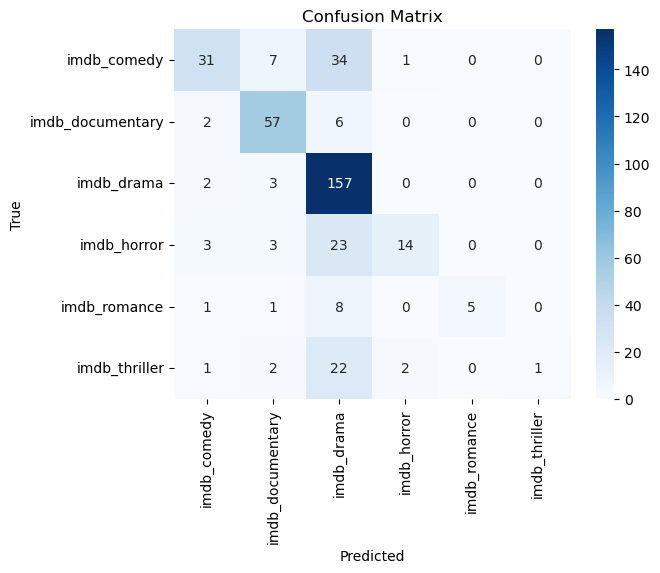

In [21]:
test(test_loader,model,loss_fnc,encoder)

# Synopsis

In [18]:
df = pd.read_csv("../data/MovieDataThread.csv")
index_drop = df.loc[df['imdb_id'].isnull()].index
df = df.drop(index=index_drop)
df = df.drop(columns=['imdb_id'])
df_filtered = pd.concat([df[['synopsis','Title']],df.filter(like='imdb_')],axis=1)
df_filtered["genre_count"] = df_filtered.filter(regex='^imdb_(?!id$)').count(axis=1)
df_filtered_one_genre = df_filtered.loc[df_filtered['genre_count'] == 1]
df_filtered_one_genre['filtered_genre'] = df_filtered_one_genre.apply(lambda row: next(iter([col for col in df_filtered_one_genre.columns if "imdb" in col and row[col] == 1.0 ]), 'unknown'), axis=1)
number_genres = len(df_filtered_one_genre['filtered_genre'].unique())
counter = Counter(df_filtered_one_genre['filtered_genre'])
sorted_list = sorted(counter.items(),reverse=True , key=lambda genre : genre[1])[: int(number_genres * (percentage_genre_to_keep / 100))]

genre_to_keep = [genre for genre,_ in sorted_list]
columns_to_keep = ['synopsis','filtered_genre']

df_synopsis = df_filtered_one_genre.loc[df_filtered_one_genre['filtered_genre'].isin(genre_to_keep)]
df_synopsis = df_synopsis[columns_to_keep].reset_index(drop=True)
df_synopsis = df_synopsis.dropna(subset=['synopsis'])


C:\Users\letru\AppData\Local\Temp\ipykernel_8364\3392877563.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_one_genre['filtered_genre'] = df_filtered_one_genre.apply(lambda row: next(iter([col for col in df_filtered_one_genre.columns if "imdb" in col and row[col] == 1.0 ]), 'unknown'), axis=1)


In [19]:
df_synopsis.shape

(1179, 2)

In [20]:
X_train,X_test , y_train,y_test = train_test_split(df_synopsis['synopsis'],df_synopsis['filtered_genre'],test_size=test_size,random_state=random_state)

In [21]:
def preprocess(script):
    tokens = word_tokenize(script.lower())
    filtered = [token for token in tokens if token.isalpha() and token not in stop_words]
    return filtered

X_train_filtered_token = [preprocess(script) for script in X_train]
X_test_filtered_token = [preprocess(script) for script in X_test]

In [22]:
word2vec = Word2Vec(sentences=X_train_filtered_token, vector_size=300, window=5, min_count=2, workers=4)

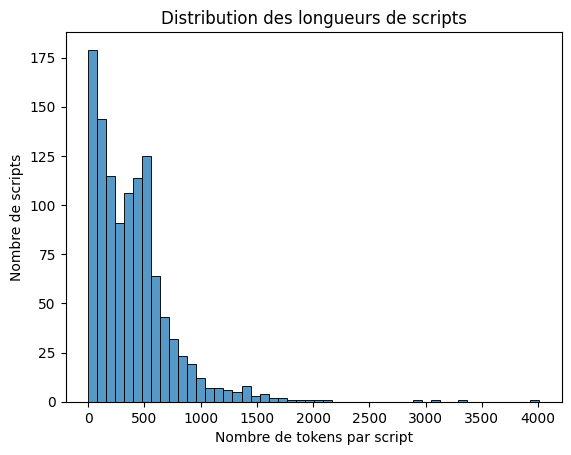

Taille max des séquences choisie : 783


In [23]:
script_lengths = [len(tokens) for tokens in X_train_filtered_token]

sns.histplot(script_lengths, bins=50)
plt.xlabel("Nombre de tokens par script")
plt.ylabel("Nombre de scripts")
plt.title("Distribution des longueurs de scripts")
plt.show()


max_seq_len = int(np.percentile(script_lengths, 90))

print(f"Taille max des séquences choisie : {max_seq_len}")

In [25]:
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)


y_tensor_train = torch.tensor(y_train_encoded,dtype=torch.long).view(-1)
y_tensor_test = torch.tensor(y_test_encoded,dtype=torch.long).view(-1)


train_dataset = ScriptDatasetLazy(X_train_filtered_token, y_train_encoded, word2vec, max_len=max_seq_len)
test_dataset  = ScriptDatasetLazy(X_test_filtered_token,  y_test_encoded, word2vec, max_len=max_seq_len)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

In [32]:
device = "cpu"
model = RNNClassfier(300,hidden_dim=128,num_layers=2).to(device)
early_stopping = EarlyStopping(patience=5, min_delta=0.0001)
loss_fnc = nn.CrossEntropyLoss()
optimizer_adam = torch.optim.Adam(model.parameters(),lr=0.001)
epochs = 3
for epoch in range(epochs):
    print(f"epoch: {epoch}")
    loss = train(train_loader,model,loss_fnc,optimizer_adam,epoch)
    if early_stopping(loss):
        print(f"Early stopping triggered at epoch {epoch} ")
        break


epoch: 0
Step: 0 Train Loss: 1.4884
epoch: 1
epoch: 2


Test Loss: 1.4970
Classification Report:
                   precision    recall  f1-score   support

     imdb_comedy       0.00      0.00      0.00        20
imdb_documentary       0.00      0.00      0.00         6
      imdb_drama       0.34      1.00      0.51        20
     imdb_horror       0.00      0.00      0.00        10
    imdb_romance       0.00      0.00      0.00         1
   imdb_thriller       0.00      0.00      0.00         2

        accuracy                           0.34        59
       macro avg       0.06      0.17      0.08        59
    weighted avg       0.11      0.34      0.17        59



d:\programmation\nlp\.venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\programmation\nlp\.venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\programmation\nlp\.venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


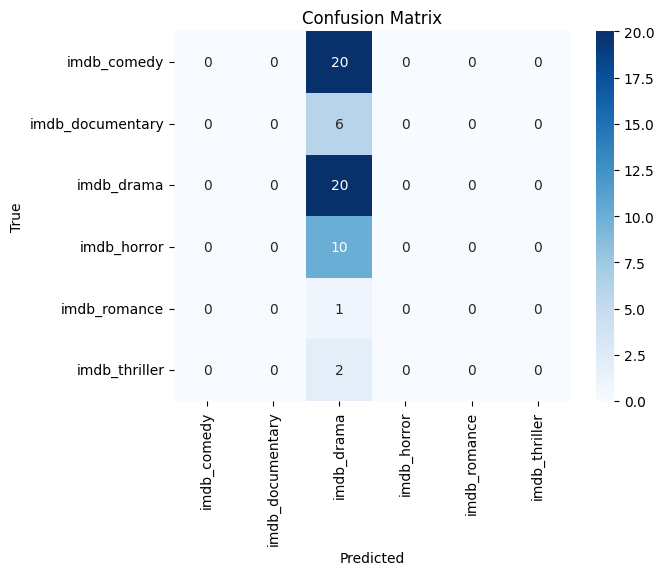

In [33]:
test(test_loader,model,loss_fnc,encoder)

# RNN with Attention

In [26]:
device = "cpu"
model = RNNClassifierWithAttention(300,hidden_dim=128,num_layers=2).to(device)
early_stopping = EarlyStopping(patience=5, min_delta=0.0001)
loss_fnc = nn.CrossEntropyLoss()
optimizer_adam = torch.optim.Adam(model.parameters(),lr=0.001)
epochs = 3
for epoch in range(epochs):
    print(f"epoch: {epoch}")
    loss = train(train_loader,model,loss_fnc,optimizer_adam,epoch)
    if early_stopping(loss):
        print(f"Early stopping triggered at epoch {epoch} ")
        break


epoch: 0
Step: 0 Train Loss: 1.4844
epoch: 1
epoch: 2


Test Loss: 1.4815
Classification Report:
                   precision    recall  f1-score   support

     imdb_comedy       0.25      0.10      0.14        20
imdb_documentary       0.00      0.00      0.00         6
      imdb_drama       0.33      0.85      0.48        20
     imdb_horror       0.00      0.00      0.00        10
    imdb_romance       0.00      0.00      0.00         1
   imdb_thriller       0.00      0.00      0.00         2

        accuracy                           0.32        59
       macro avg       0.10      0.16      0.10        59
    weighted avg       0.20      0.32      0.21        59



d:\programmation\nlp\.venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\programmation\nlp\.venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\programmation\nlp\.venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


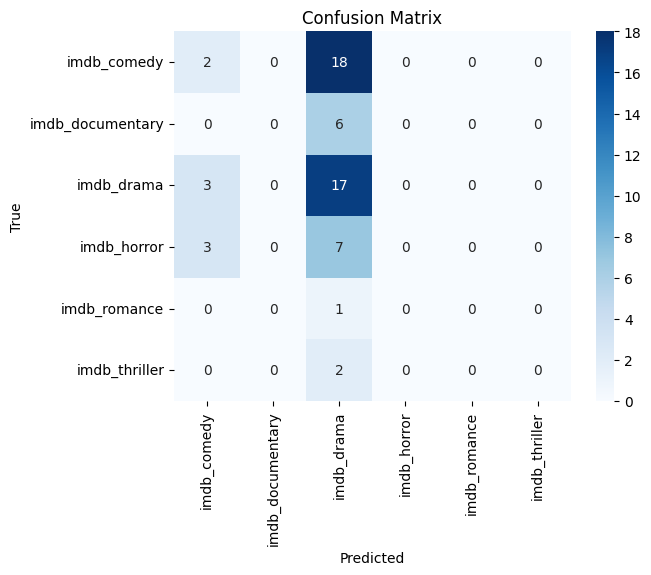

In [27]:
test(test_loader,model,loss_fnc,encoder)